# Task 8.2 D
### Name: Nay Tun
### Student Id: 225110052
### Google Colab link - https://colab.research.google.com/github/nay-deakin/sit720-data/blob/main/NayTun225110052_Task8.2D.ipynb

In [321]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedShuffleSplit, RandomizedSearchCV, KFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import time
from sklearn.neighbors import KNeighborsClassifier
import ast
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
import shap
import joblib


# 1. Melbourne Housing Data acquisition: choose the top three suburbs that you want to live in Melbourne, leverage realestate.com.au to manually collect at least 150 housing data points (at least 50 for each suburb). For each housing data point, prepare as many features as you can, example features are property type, location, number of bedrooms/bathrooms, land size, sale date, etc. The target variable is sold price.

### Terms of service on realestate.com.au does not allow scrapping so manually created an excel file
### 3 Surburbs Chosen St Kilda (3182), Footscray (3011), Northcote (3070)

In [150]:
df = pd.read_excel("https://github.com/nay-deakin/sit720-data/raw/refs/heads/main/real_estate_manual_with_lat_long_2.xlsx", sheet_name="Sheet1")
df.head()

,sold_price,suburb,postcode,address,property_type,bedrooms,bathrooms,car_spaces,property_size_sqm,sold_on,lat_lon
0,3600000,St Kilda,3182,34 Robe Street,House,3,2,2,577,2025-12-09,"(-37.8636674, 144.9794538)"
1,3175000,St Kilda,3182,2 Marine Parade,House,3,2,2,310,2025-09-17,"(-37.882398, 147.9735052)"
2,2000000,St Kilda,3182,36 Gurner Street,House,5,2,1,391,2025-09-04,"(-37.8607976, 144.9821088)"
3,2850000,St Kilda,3182,25 Burnett Street,House,5,2,1,511,2025-07-02,"(-37.6391567, 144.9658612)"
4,1500000,St Kilda,3182,18 Fawkner Street,House,4,2,2,303,2024-12-16,"(-37.8421189, 144.9872064)"


### Use overpy geopy to get some more features
### Got help from claude prompt: provide a free api to get the following features by passing address, Distance from CBD, number of schools neaby, number of bus_stop nearby and number super markets nearby.  Nearby is defined as with 2KM

In [244]:
pip install geopy overpy osmnx shap


Note: you may need to restart the kernel to use updated packages.


## Geopy overpy osmnx stuff

## Using open street map to get the following extra features
- Distance from CBD in km
- Distance schools in km (2km radius search)
- Distance from hospitals in km (2km radius search)
- Distance from supermarkets in km (2km radius search)
- Distance from train stations in km (within 500m for walking distance)
- Distance from tram stops in km (within 500m for walking distance)
- Distance from bus stops in km (within 500m for walking distance)
- Number of schools with 2km radius
- Number of hospitals with 2km radius
- Number of supermarkets with 2km radius
- Number of train stations within 500m walking distance
- Number of tram stops within 500m walking distance
- Number of bus stops within 500m walking distance
- 2 functions to do this get_nearest_poi_km to get the distance and get_nearest_poi_count to get the number
- Before calling these function to speed things up, call get suburb poi which gets all the poi (pass parameter to say which one you want) with the 3 suburbs in question as centers
- Then call the POI distance or count function by passing the Dataframes with all the interested POI.
- Then use geodesic library to get the distance between the 2 coordinate points
- Helper function get_coords is also written to covert the address to Latitude and Longitude.

In [152]:
import overpy
from geopy.distance import geodesic
from geopy.geocoders import Nominatim
import time
import osmnx as ox

geolocator = Nominatim(user_agent="sit720")
# api = overpy.Overpass(url="https://overpass.kumi.systems/api/interpreter") this does not work, too slow to run and constantly times out so using osmnx

def get_coords(address):
    time.sleep(1)
    location = geolocator.geocode(f"{address}, VIC, Australia")
    if location:
        return (location.latitude, location.longitude)
    return None

def get_nearest_poi_km(gdf, coords, radius=2000 ): # 5km radius
    large_distance = 99
    try:
        gdf = gdf.reset_index()
        distances = gdf['geometry'].apply(lambda x: geodesic(coords, (x.centroid.y, x.centroid.x)).km)
        radius_km = radius / 1000  # convert metres to km
        distances = distances[distances <= radius_km]
        if len(distances) == 0:
            return large_distance
        return float(distances.max())
    except:
        return large_distance
    
def get_nearest_poi_count(gdf, coords, radius=2000 ): # 2km radius close within 2km
    try:
        distances = gdf['geometry'].apply(lambda x: geodesic(coords, (x.centroid.y, x.centroid.x)).km)
        radius_km = radius / 1000  # convert metres to km
        distances = distances[distances <= radius_km]
        return len(distances)
    except:
        return 0
    
def get_distance_cbd(coords):
    CBD_COORDS = (-37.8136, 144.9631)
    try:
        return geodesic(CBD_COORDS, coords).km
    except:
        return None
    
def get_suburb_poi(poi_tag, poi_type, radius=5000):
    # Use suburb centre coords instead of individual addresses

    suburb_centres = {
        'St Kilda':   (-37.8640, 144.9820),
        'Northcote':  (-37.7722, 144.9994),
        'Footscray':  (-37.7990, 144.9000),

    }
    gdf_list = []
    for suburb in suburb_centres:
        lat, lon = suburb_centres[suburb]
        try:
            gdf = ox.features_from_point(
                (lat, lon),
                tags={poi_tag: poi_type},
                dist=radius
            )
            gdf = gdf.reset_index()
            gdf['suburb'] = suburb
            gdf_list.append(gdf)
        except:
            pass
    if len (gdf_list) > 0:
        gdf = pd.concat(gdf_list).reset_index(drop=True)        
    else:
        gdf = pd.DataFrame()
    return gdf
            
    

# this will take almost 4 min so generate a file with lat long so we don't have to wait 4 min

In [153]:
# df["lat_lon"] = df["address"].apply(get_coords)

In [192]:
try:
    df['lat_lon'] = df['lat_lon'].apply(ast.literal_eval)        
except:
    pass

df["km_from_cbd"] = df["lat_lon"].apply(get_distance_cbd)
df["km_from_cbd_inv"] = 1 / (df["km_from_cbd"] + 0.0001) 

In [155]:
gdf_school = get_suburb_poi("amenity", "school")
gdf_hospital = get_suburb_poi("amenity", "hospital")
gdf_supermarket = get_suburb_poi("amenity", "supermarket")
gdf_trainstation = get_suburb_poi("railway", "station")
gdf_tramstop = get_suburb_poi("railway", "tram_stop")
gdf_bustop = get_suburb_poi("highway", "bus_stop")

In [156]:
if len(gdf_school) > 0:
    df["km_from_school"] = df["lat_lon"].apply(lambda x: get_nearest_poi_km(gdf_school, x))
    df["count_school"] = df["lat_lon"].apply(lambda x: get_nearest_poi_count(gdf_school, x))

if len(gdf_hospital) > 0:
    df["km_from_hospital"] = df["lat_lon"].apply(lambda x: get_nearest_poi_km(gdf_hospital, x))
    df["count_hospital"] = df["lat_lon"].apply(lambda x: get_nearest_poi_count(gdf_hospital, x))
    
if len(gdf_supermarket) > 0:
    df["km_from_supermarket"] = df["lat_lon"].apply(lambda x: get_nearest_poi_km(gdf_supermarket, x))
    df["count_supermarket"] = df["lat_lon"].apply(lambda x: get_nearest_poi_count(gdf_supermarket, x))
    
if len(gdf_trainstation) > 0:
    df["km_from_trainstation"] = df["lat_lon"].apply(lambda x: get_nearest_poi_km(gdf_trainstation, x, 500))
    df["count_trainstation"] = df["lat_lon"].apply(lambda x: get_nearest_poi_count(gdf_trainstation, x, 500))
    
if len(gdf_tramstop) > 0:
    df["km_from_tramstop"] = df["lat_lon"].apply(lambda x: get_nearest_poi_km(gdf_tramstop, x, 500))
    df["count_tramstop"] = df["lat_lon"].apply(lambda x: get_nearest_poi_count(gdf_tramstop, x, 500))
    
if len(gdf_bustop) > 0:
    df["km_from_busstop"] = df["lat_lon"].apply(lambda x: get_nearest_poi_km(gdf_bustop, x, 500))
    df["count_busstop"] = df["lat_lon"].apply(lambda x: get_nearest_poi_count(gdf_bustop, x, 500))                

### Have to invert the distance fields
### You would want the model to know a positive impact to the prices as the distances are closer

In [193]:
df['km_from_school_inv']    = 1 / (df['km_from_school'] + 0.0001)
df['km_from_hospital_inv']  = 1 / (df['km_from_hospital'] + 0.0001)
df['km_from_trainstation_inv'] = 1 / (df['km_from_trainstation'] + 0.0001)
df['km_from_tramstop_inv'] = 1 / (df['km_from_tramstop'] + 0.0001)
df['km_from_busstop_inv']   = 1 / (df['km_from_busstop'] + 0.0001)

## Suburb and their price range

In [158]:
df.groupby('suburb')['sold_price'].agg(['min','max','mean'])

,min,max,mean
suburb,,,
Footscray,720000,2655000,1097905.00
Northcote,930000,3670000,2010736.34
St Kilda,1220000,5650000,2428215.00


### Now that we got all our features, including the engineered ones, we will split them to categorical and numerical columns

In [264]:
target_cols = ['sold_price']

numerical_cols_scale = [
    'bedrooms', 'bathrooms', 'car_spaces', 
    'property_size_sqm', 'km_from_school_inv', 'count_school', 
    'km_from_hospital_inv', 'count_hospital', 'km_from_trainstation_inv',
    'count_trainstation', 'km_from_tramstop_inv', 'count_tramstop',
    'km_from_busstop_inv', 'count_busstop', 'km_from_cbd_inv'
]


nominal_cols = [
    'suburb', 'property_type'
]

# Create 3 pipelines
- One for categorical for OHE transformation
- Another for numerical no scaling
- Another for numerical with standard scaler



In [265]:
nominal_pipeline = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer([
    ('nominal', nominal_pipeline, nominal_cols),
    ('numeric_scale', StandardScaler(), numerical_cols_scale),
])



In [287]:
X = df[numerical_cols_scale + numerical_cols_noscale + nominal_cols]
y = df[target_cols[0]]



In [289]:
X_preproc = preprocessor.fit_transform(X,y)
x_features = preprocessor.get_feature_names_out()
X_preproc_df = pd.DataFrame(X_preproc, columns = x_features)
X_preproc_df['target'] = y.values
X_preproc_df.head()

,nominal__suburb_Footscray,nominal__suburb_Northcote,nominal__suburb_St Kilda,nominal__property_type_House,nominal__property_type_Townhouse,nominal__property_type_Villa,numeric_scale__bedrooms,numeric_scale__bathrooms,numeric_scale__car_spaces,numeric_scale__property_size_sqm,...,numeric_scale__km_from_hospital_inv,numeric_scale__count_hospital,numeric_scale__km_from_trainstation_inv,numeric_scale__count_trainstation,numeric_scale__km_from_tramstop_inv,numeric_scale__count_tramstop,numeric_scale__km_from_busstop_inv,numeric_scale__count_busstop,numeric_scale__km_from_cbd_inv,target
0,0.0,0.0,1.0,1.0,0.0,0.0,-0.435371,0.581722,-0.087149,0.966937,...,0.148090,0.019163,-0.472586,-0.565685,0.958771,0.829347,0.577500,0.640765,0.193279,3600000
1,0.0,0.0,1.0,1.0,0.0,0.0,-0.435371,0.581722,-0.087149,-0.724959,...,-1.092013,-0.619613,-0.472586,-0.565685,-1.008237,-0.770108,-1.493258,-1.185644,-1.285071,3175000
2,0.0,0.0,1.0,1.0,0.0,0.0,1.983355,0.581722,-0.958638,-0.211688,...,0.155267,0.338552,-0.472586,-0.565685,0.929861,1.895649,0.948044,0.298314,0.259556,2000000
3,0.0,0.0,1.0,1.0,0.0,0.0,1.983355,0.581722,-0.958638,0.548715,...,-1.092013,-0.619613,-0.472586,-0.565685,-1.008237,-0.770108,-1.493258,-1.185644,-0.869807,2850000
4,0.0,0.0,1.0,1.0,0.0,0.0,0.773992,0.581722,-0.087149,-0.769316,...,0.303462,0.338552,-0.472586,-0.565685,0.863536,0.473912,0.623049,0.070012,0.958338,1500000


<Axes: >

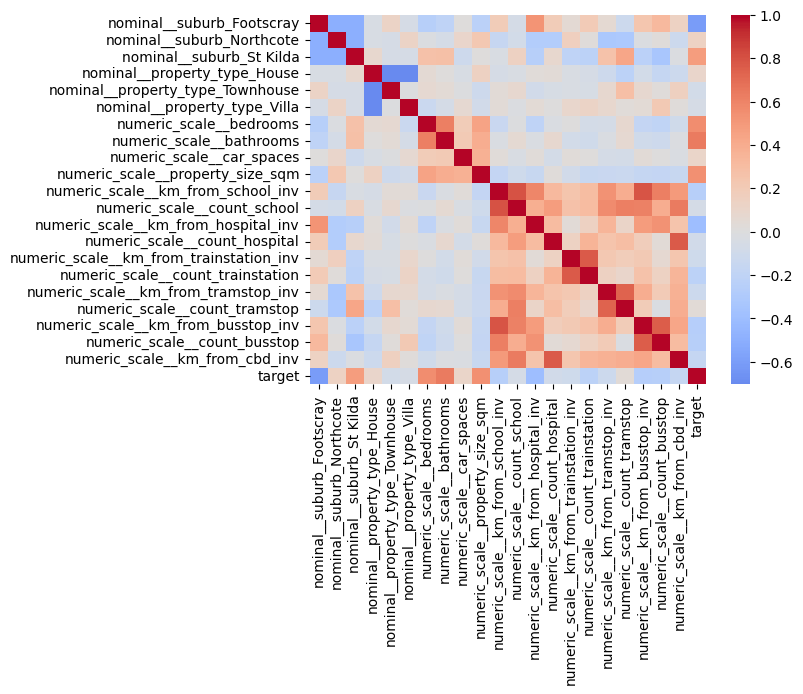

In [290]:
sns.heatmap(X_preproc_df.corr(), cmap='coolwarm', center=0)

### Top 10 positive correlated Features to the target (sold_price)

In [269]:
# Top 10 most positive correlated features
X_preproc_df.corr()['target'].sort_values(ascending=False).drop('target').head(10)

numeric_scale__bathrooms            0.622607
numeric_scale__property_size_sqm    0.552723
numeric_scale__bedrooms             0.541172
nominal__suburb_St Kilda            0.487281
numeric_scale__car_spaces           0.157913
nominal__suburb_Northcote           0.146654
nominal__property_type_House        0.114012
numeric_scale__count_tramstop       0.065280
numeric_scale__count_school         0.007657
nominal__property_type_Villa       -0.062698
Name: target, dtype: float64

### This show the more bathrooms, larger property size and more bedrooms has positive correlation, the price increase
### St Kilda also has a positive correlation, meaning it is the suburb with the more expensive houses
### Having schools and tram stop nearby seems to increase the price.

### Top 10 negative correlated Features to the target (sold_price)

In [270]:
# Top 10 most negative correlated features
X_preproc_df.corr()['target'].sort_values(ascending=True).drop('target').head(10)

nominal__suburb_Footscray                 -0.647247
numeric_scale__km_from_hospital_inv       -0.372029
numeric_scale__count_trainstation         -0.238178
numeric_scale__count_busstop              -0.173491
numeric_scale__km_from_school_inv         -0.136855
numeric_scale__km_from_busstop_inv        -0.124368
numeric_scale__km_from_cbd_inv            -0.117837
nominal__property_type_Townhouse          -0.097860
numeric_scale__km_from_trainstation_inv   -0.089158
numeric_scale__km_from_tramstop_inv       -0.072712
Name: target, dtype: float64

### Footscray has the most negative correlation as all the cheaper houses are in this suburb out the 3 chosen
### Being close to hospital lowers the price ?
### Also overtime the prices are decreasing (year having a negative correlation)
### Having too many stations and bus stops near by seems to lower the prices?
### being far from schoos, bus stops and CBD lowers the prices

### Check outliers for the price sold

In [271]:
import matplotlib.pyplot as plt
import numpy as np

# Statistics
Q1 = df['sold_price'].quantile(0.25)
Q3 = df['sold_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['sold_price'] < lower_bound) | (df['sold_price'] > upper_bound)]

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Outliers: {len(outliers)} properties")
print(outliers[['address', 'suburb', 'sold_price', 'property_type', 'bedrooms', 'bathrooms', 'property_size_sqm']])

Q1: 1130000.0
Q3: 2375000.0
IQR: 1245000.0
Lower bound: -737500.0
Upper bound: 4242500.0
Outliers: 2 properties
            address    suburb  sold_price property_type  bedrooms  bathrooms  \
29  14 Baker Street  St Kilda     4450000         House         4          4   
31   9 Baker Street  St Kilda     5650000         House         5          4   

    property_size_sqm  
29                654  
31                598  


### 2 outliers in terms of price.
### Looks like some big mansions being sold in St Kilda

In [272]:
df['year/month'] = df['sold_on'].dt.strftime('%Y')

In [273]:
dfym = df.groupby('year/month')['sold_price'].agg(['min','mean','max']).reset_index()
dfym = dfym.sort_values('year/month')
dfym

,year/month,min,mean,max
0,2015,1220000,1.220000e+06,1220000
1,2017,1435000,1.945000e+06,2455000
2,2021,1750000,2.285000e+06,2730000
3,2022,1800000,2.478889e+06,3090000
4,2023,1465000,2.255833e+06,3795000
5,2024,1000000,2.467357e+06,5650000
6,2025,720000,1.762054e+06,3900000
7,2026,750000,1.445078e+06,3140000


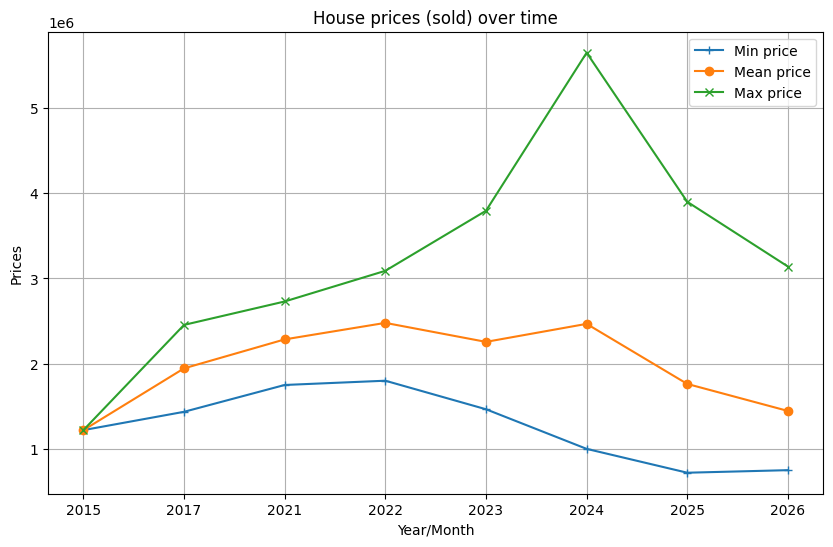

In [274]:
plt.figure(figsize=(10, 6))
plt.plot(dfym['year/month'].values, dfym['min'].values, label='Min price', marker='+')
plt.plot(dfym['year/month'].values, dfym['mean'].values, label='Mean price', marker='o')
plt.plot(dfym['year/month'].values, dfym['max'].values, label='Max price', marker='x')
plt.xlabel('Year/Month')
plt.ylabel('Prices')
plt.title('House prices (sold) over time')
plt.legend()
plt.xticks(dfym['year/month'].values)
plt.grid(True)
plt.show()

### Prices at the lower end started dropping since 2022
### Prices at the upper end dramatically increases around 2023, 2024
### But this data is only a small sample so it may no represent the real trend.
### General drop in 2025 - 2026 due to the RBA increasing the interest rates in late 2024

#

In [275]:
dfsuburb = df.groupby(['year/month', 'suburb'])['sold_price'].agg(['mean']).reset_index()
dfsuburb = dfsuburb.sort_values('year/month')
dfsuburb

,year/month,suburb,mean
0,2015,St Kilda,1.220000e+06
1,2017,St Kilda,1.945000e+06
2,2021,St Kilda,2.285000e+06
3,2022,St Kilda,2.478889e+06
4,2023,St Kilda,2.255833e+06
5,2024,Footscray,1.000000e+06
6,2024,Northcote,2.250000e+06
7,2024,St Kilda,2.607750e+06
8,2025,Footscray,1.142764e+06
9,2025,Northcote,2.084300e+06


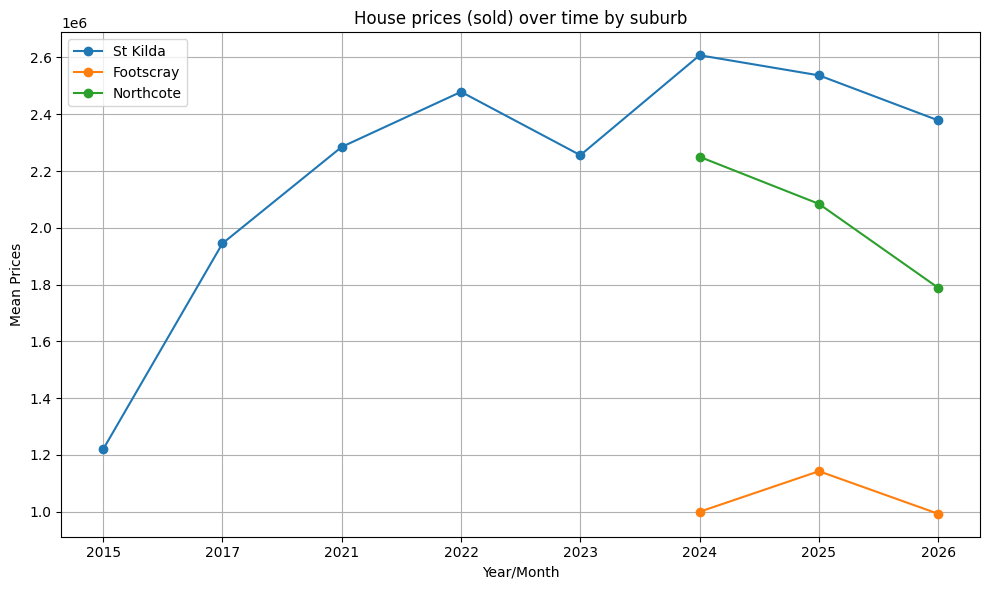

In [276]:
fig, ax = plt.subplots(figsize=(10, 6))

for suburb in dfsuburb['suburb'].unique():
    suburb_data = dfsuburb[dfsuburb['suburb'] == suburb].sort_values('year/month')
    ax.plot(suburb_data['year/month'], suburb_data['mean'], label=suburb, marker='o')
plt.xlabel('Year/Month')    
plt.ylabel('Mean Prices')
plt.title('House prices (sold) over time by suburb')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Looking at this chart I believe my pick for the sample data is not comprehensive enough.
### Missing past data for Footscray and Northcote
### As observed by the year chart, this explain why the rise at the high end is observed as there are more data for St Kilda with the higher prices
### while the other suburbs are missing historical data post 2024. But the down turn is clearly seen here as well

#

# 3. Model development and evaluations: develop at least three different regression models, use MAE, RMSE and R-squared as the evaluation metrics, use k-fold cross validation to evaluate the model performance. 

In [346]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=1)
}
kf = KFold(n_splits=5, shuffle=True, random_state=1)

scoring = {
    'mae': 'neg_mean_absolute_error'
    , 'rmse': 'neg_root_mean_squared_error'
    , 'r2': 'r2'
}

results = []

for name in models:
    model = models[name]
    pipe = Pipeline([
        ('preprocessor', preprocessor)
        , ('regressor', model)
    ])
    cv_results = cross_validate(
        pipe, X, y
        , cv=kf
        , scoring=scoring
        , return_train_score=False
    )
    cols = []
    cols.append(name)
    cols.append(-cv_results['test_mae'].mean())
    cols.append(-cv_results['test_rmse'].mean())
    cols.append(cv_results['test_r2'].mean())
    results.append(cols)
        
    
results_df = pd.DataFrame(results, columns= ['model', 'MAE', 'RMSE', 'R2'])
print(results_df.sort_values('R2', ascending=False))


               model            MAE           RMSE        R2
2  Gradient Boosting  333347.246417  492570.764611  0.641783
1      Random Forest  366205.273067  543686.339955  0.566540
0  Linear Regression  373742.302949  517362.535956  0.531081


### Probably need to tune it
### lets use the best model Gradient Boosting, tune it and use that for feature importance (SHAP)
### GB will be our production model for streamlit

In [347]:
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=1)),
])

param_grid = {
        'regressor__max_depth': [3, 5, 10, 15, 20, 25],
        'regressor__n_estimators': [10, 20, 30, 40, 50, 60],
        'regressor__learning_rate': [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
    }
grid_search = GridSearchCV(
    gb_model,
    param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X, y)
print (f"Best params: {grid_search.best_params_}")
print (f"Best model RMSE: {grid_search.best_score_}")

Best params: {'regressor__learning_rate': 0.2, 'regressor__max_depth': 3, 'regressor__n_estimators': 20}
Best model RMSE: -472167.70198418666


In [348]:
cv_results = cross_validate(
    grid_search.best_estimator_,
    X, y,
    cv=kf,
    scoring={
        'mae':  'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2':   'r2'
    }
)

print(f"MAE: {-cv_results['test_mae'].mean()}")
print(f"RMSE: {-cv_results['test_rmse'].mean()}")
print(f"R2: {cv_results['test_r2'].mean()}")

MAE: 319492.8746085287
RMSE: 472167.70198418666
R2: 0.6699548537279769


In [350]:
new_row = pd.DataFrame([{
    'model': 'Gradient Boosting (Tuned)',
    'MAE':  -cv_results['test_mae'].mean(),
    'RMSE': -cv_results['test_rmse'].mean(),
    'R2':   cv_results['test_r2'].mean()
}],)

results_df = pd.concat([results_df, new_row])

### Improved the R2 a bit but still a large gap before being a reliable regressor.
### Roughly the estimation if off by avg of 472K which is not that good of a result.

#


# 4. Feature importance: identify which features more influence housing price, use  model-specific  methods  (e.g.,  feature  importance  in  tree-based methods) or other statistical methods (e.g., SHAP values).

### Used LLM to get sample code to show feature importance using SHAP
- Prompt: Give me sample code for feature importance using SHAP for my tuned gradient boost best estimator

In [280]:
best_pipeline = grid_search.best_estimator_
preprocessor_fit = best_pipeline.named_steps['preprocessor']
regressor = best_pipeline.named_steps['regressor']

In [281]:
X_transformed  = preprocessor_fit.transform(X)
feature_names  = preprocessor_fit.get_feature_names_out()

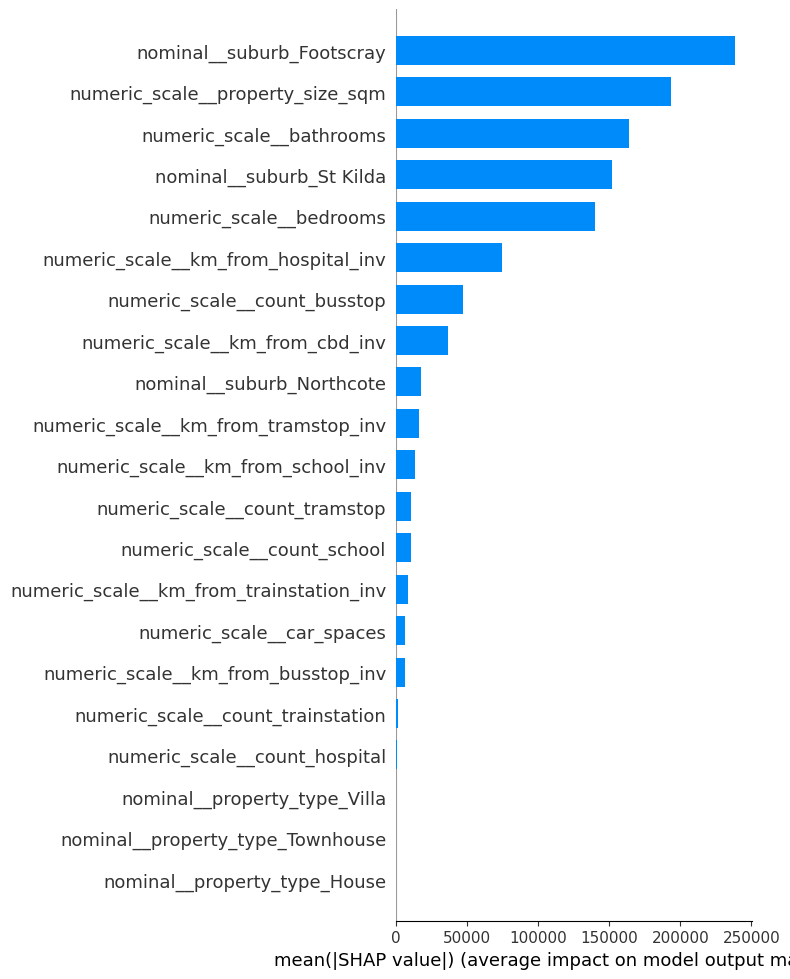

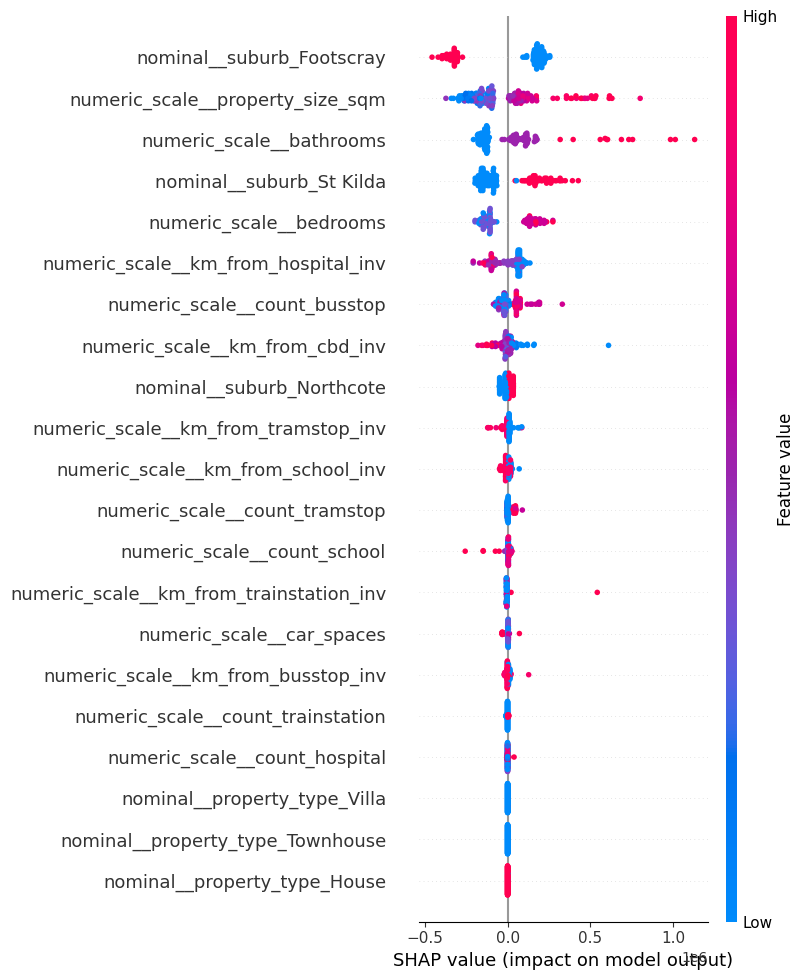

In [282]:
# LLM code
# ── SHAP values ────────────────────────────────────────────────
explainer   = shap.TreeExplainer(regressor)
shap_values = explainer.shap_values(X_transformed)

# Bar plot — overall importance
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type='bar',
    max_display=25
)

# Summary plot — direction + magnitude
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    max_display=25
)
# personal note: this will now will be in my saved archive of sample codes.  More useful to look at compared the built in tree feature importance in my opinion

- So reading the first chart, footscray will shift the price by 250k and the property size will shift the price by 200k in the predictions
- The bottom chart, for footscray - red dots will be footscray=1 and blue dots will be footscray=0.  Knowing footscray, the prices will be lower and know not in footscray the prices will be higher
- For the property size, red dots are large properties and blue dots are small propertis.  Large properties pushes the price up and small one pushes the price down.  Which makes sense


## Save the best estimator for the steamlit app

In [283]:
model_artifacts = {
    'pipeline': best_pipeline,
}
joblib.dump(model_artifacts, 'house_pred_model.pkl')

['house_pred_model.pkl']

## Model load this

In [284]:
artifacts = joblib.load('house_pred_model.pkl')
pipeline = artifacts['pipeline']
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nominal', ...), ('numeric_scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

# 5.  Model  deployment:  Develop  a  simple  web  demo  application  using appropriate packages (e.g., gradio, Flask or Streamlit). Allow users to input property features and receive price predictions. 

### Ah web app, maybe I went overboard with the engineered features.  Now the app has to cater for 17 features or 17 input values.
### In a real world app most of the engineered features can be minimized to just getting the user to enter the address
### However I think I am running out of time so in stream list I will just create 17 drop down box

In [ ]:
# pip install streamlit
# #this code should be in app.py
# #streamlit run app.py

# import streamlit as st
# import joblib
# import pandas as pd
# import requests
# import joblib
# import io

# st.set_page_config(layout="wide")
# st.markdown(
#         r"""
#         <style>
#         #MainMenu {visibility: hidden;}
#         .stAppDeployButton {
#                 visibility: hidden;
#             }
#         </style>
#         """, unsafe_allow_html=True
#     )

# # Load the model
# url = "https://raw.githubusercontent.com/nay-deakin/sit720-data/main/house_pred_model.pkl"
# response = requests.get(url)
# artifacts = joblib.load(io.BytesIO(response.content))
# pipeline = artifacts['pipeline']    


# st.title("Too many inputs House Price Predictor")

# col1, col2 = st.columns(2)
# with col1:
#     suburb = st.selectbox(
#         "Suburb"
#         , ("St Kilda", "Footscray", "Northcote")
#     )

# with col2: 
#     property_type = st.selectbox(
#         "Property Type"
#         , ('House', 'Townhouse', 'Villa')
#     )


# col1, col2, col3, col4 = st.columns(4)
# with col1:
#     bedrooms = st.selectbox(
#         "Number of bedrooms"
#         , (1,2,3,4,5,6)
#     )

# with col2:
#     bathrooms = st.selectbox(
#         "Number of bathrooms"
#         , (1,2,3,4)
#         , index=0
#     )

# with col3:
#     car_spaces = st.selectbox(
#         "Number of car spaces"
#         , (0,1,2,3)
#         , index=0
#     )

# with col4:
#     property_size_sqm = st.number_input(
#         "Property size in Sq meters"
#         , min_value=0
#     )
    
# col1, col2, col3, col4 = st.columns(4)
# with col1:
#     km_from_school = st.selectbox(
#         "Distance from School in km"
#         , (0.5,1,2,3,4,5)
#         , index=0
#     )

# with col2:
#     count_school = st.number_input(
#         "# of schools within 2km"
#         , min_value=0
#     )

# with col3:
#     km_from_hospital = st.selectbox(
#         "Distance from Hospital in km"
#         , (0.5,1,2,3,4,5)
#         , index=0
#     )

# with col4:
#     count_hospital = st.number_input(
#         "# of hospitals within 2km"
#         , min_value=0
#     ) 
    
# col1, col2, col3, col4 = st.columns(4)
# with col1:
#     km_from_trainstation = st.selectbox(
#         "Distance from Train Station in km"
#         , (0.5,1,2,3,4,5)
#         , index=0
#     )

# with col2:
#     count_trainstation = st.number_input(
#         "# of train stations within 500m"
#         , min_value=0
#     )

# with col3:
#     km_from_tramstop = st.selectbox(
#         "Distance from Tram Stop in km"
#         , (0.5,1,2,3,4,5)
#         , index=0
#     )

# with col4:
#     count_tramstop = st.number_input(
#         "# of Tram stops within 500m"
#         , min_value=0
#     ) 
    
# col1, col2, col3 = st.columns(3)
# with col1:
#     km_from_busstop = st.selectbox(
#         "Distance from Bus Stop in km"
#         , (0.5,1,2,3,4,5)
#         , index=0
#     )

# with col2:
#     count_busstop = st.number_input(
#         "# of bus stops within 500m"
#         , min_value=0
#     )

# with col3:
#     km_from_cbd = st.selectbox(
#         "Distance from CBD in km"
#         , (1,2,3,4,5,6,7,8,9,10)
#         , index=0
#     )
    

# runpred = st.button("Predict Price")
# if runpred:
#     with st.spinner("Predicting price ..."):
#         X = pd.DataFrame(
#             [
#                 [
#                     suburb, property_type
#                     , bedrooms, bathrooms, car_spaces, property_size_sqm
#                     , 1/(km_from_school+0.0001), count_school, 1/(km_from_hospital+0.0001), count_hospital
#                     , 1/(km_from_trainstation+0.0001), count_trainstation, 1/(km_from_tramstop+0.0001), count_tramstop
#                     , 1/(km_from_busstop+0.0001), count_busstop, 1/(km_from_cbd+0.0001)
#                 ]
#             ], columns = [
#                 "suburb", "property_type"
#                 , "bedrooms", "bathrooms", "car_spaces", "property_size_sqm"
#                 , "km_from_school_inv", "count_school", "km_from_hospital_inv", "count_hospital"
#                 , "km_from_trainstation_inv", "count_trainstation", "km_from_tramstop_inv", "count_tramstop"
#                 , "km_from_busstop_inv", "count_busstop", "km_from_cbd_inv"
#             ]
#         )

#         st.dataframe(X)
#         X.to_csv("features_from_app.csv", index=False)
#         prediction = pipeline.predict(X)
#         st.subheader(f"Predicted price: ${prediction[0]:,.0f}")
        

![image description](app_screenshot.png)

#


# 6. Further comparison with a large language model: choose a large language model (e.g. ChatGPT, Gemini, Claude, etc), use the large language model to do the prediction on one fold of your data set,. Compare whether it is better or worse than the above constructed regression models. 

In [293]:
train_idx, test_idx = next(iter(kf.split(X, y)))

X_train_1fold = X.iloc[train_idx]
X_test_1fold  = X.iloc[test_idx]
y_train_1fold = y.iloc[train_idx]
y_test_1fold  = y.iloc[test_idx]

In [294]:
# pip install anthropic

### Test code

In [ ]:
import anthropic

api_key = "API_KEY" #place holder I don't want to share my actual key

client = anthropic.Anthropic(api_key=api_key, base_url="https://api.anthropic.com")

# Simple test
message = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=10,
    messages=[{"role": "user", "content": "Hi"}]
)
print(message.content[0].text)

Hi there! How are you doing? Is there


### Prompt claude for sample code

In [322]:
import anthropic
client = anthropic.Anthropic(api_key=api_key,
    base_url="https://api.anthropic.com"
)

predictions = []
train_examples = "\n".join([
    f"Property: {row.to_dict()} -> Sold for: ${y_train_1fold.iloc[i]:,.0f}"
    for i, (_, row) in enumerate(X_train_1fold.iterrows())
][:20])



for i, (_, row) in enumerate(X_test_1fold.iterrows()):
    prompt = f"""You are a Melbourne property price predictor.
Here are recent property sales:
{train_examples}

Predict the sold price for this property:
{row.to_dict()}

Reply with ONLY a single number. No text, no dollar sign, no commas."""

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=50,
        messages=[{"role": "user", "content": prompt}]
    )

    try:
        price = float(
            response.content[0].text.strip()
            .replace('$', '').replace(',', '')
        )
    except:
        price = float(y_train_1fold.mean())

    predictions.append(price)
    print(f"Predicted {i+1}/30: ${price:,.0f} | Actual: ${y_test_1fold.iloc[i]:,.0f}")


    
    
mae  = mean_absolute_error(y_test_1fold, predictions)
rmse = np.sqrt(mean_squared_error(y_test_1fold, predictions))
r2   = r2_score(y_test_1fold, predictions)

print(f"\nClaude LLM MAE:  ${mae:,.0f}")
print(f"Claude LLM RMSE: ${rmse:,.0f}")
print(f"Claude LLM R2:   {r2:.3f}")

Predicted 1/30: $1,350,000 | Actual: $1,360,000
Predicted 2/30: $2,350,000 | Actual: $2,150,000
Predicted 3/30: $2,350,000 | Actual: $2,660,000
Predicted 4/30: $2,350,000 | Actual: $3,070,000
Predicted 5/30: $3,400,000 | Actual: $4,450,000
Predicted 6/30: $3,800,000 | Actual: $5,650,000
Predicted 7/30: $1,350,000 | Actual: $1,321,000
Predicted 8/30: $1,850,000 | Actual: $1,806,750
Predicted 9/30: $1,350,000 | Actual: $1,530,000
Predicted 10/30: $1,950,000 | Actual: $1,220,000
Predicted 11/30: $2,050,000 | Actual: $2,730,000
Predicted 12/30: $1,350,000 | Actual: $1,230,000
Predicted 13/30: $1,200,000 | Actual: $1,050,000
Predicted 14/30: $1,050,000 | Actual: $845,000
Predicted 15/30: $1,250,000 | Actual: $1,200,000
Predicted 16/30: $2,100,000 | Actual: $1,240,000
Predicted 17/30: $2,100,000 | Actual: $1,367,500
Predicted 18/30: $1,100,000 | Actual: $1,051,250
Predicted 19/30: $1,650,000 | Actual: $1,015,000
Predicted 20/30: $1,850,000 | Actual: $1,460,000
Predicted 21/30: $1,850,000 | A

In [351]:
new_row = pd.DataFrame([{
    'model': 'Claude LLM',
    'MAE':  mae,
    'RMSE': rmse,
    'R2':   r2
}])

results_df = pd.concat([results_df, new_row])

print(results_df.sort_values('R2', ascending=False))

                       model            MAE           RMSE        R2
0                 Claude LLM  445400.000000  603193.573822  0.695572
0  Gradient Boosting (Tuned)  319492.874609  472167.701984  0.669955
2          Gradient Boosting  333347.246417  492570.764611  0.641783
1              Random Forest  366205.273067  543686.339955  0.566540
0          Linear Regression  373742.302949  517362.535956  0.531081


### Claude LLM came out on top with the highest R2. This was unexpected as it only saw 20 training examples.  Howerver it still does have the higher MAE and RMSE compared to the tuned gradient boosting model. Overall the result is pretty good for the LLM.  Maybe due to the small dataset.  But the tuned purpose-built regression model still out-performs it when it comes to prediction accuracy.